# Housing Price Prediction in Ho Chi Minh City via Machine Learning

**Course:** AIL303m &nbsp;|&nbsp;  **Supervisor:** HuyNX23 &nbsp;|&nbsp;
**Authors**: Doan Minh Phuc (SE190072)

This notebook reproduces the pipeline of Truong et al. (2020) on a dataset of
HCMC residential property listings. It is a thin, readable wrapper around the
reusable modules in `src/` — the actual logic (cleaning, encoding,
modelling) lives there so it can be unit tested and reused from `train.py` /
`predict.py` as well.

**Note on this version vs. the original coursework notebook:** while
reviewing the original notebook we found the `communityAverage`
feature was computed on the *full* dataset before the train/test split,
which is a data leakage bug (the test set influenced a feature it was later
evaluated on). This notebook fixes that — `communityAverage` is now
computed from the training fold only, exactly like `District`/`Ward` target
encoding. As a result, the RMSLE numbers below are a few thousandths higher
than the original headline numbers, but are the trustworthy ones.


## 1. Setup

In [1]:
import sys
from pathlib import Path

# Add project root to sys.path so we can import src/
# Notebook is in notebooks/, go up 1 level to reach project root
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import load_raw, clean
from src.features import BASE_FEATURES, build_encoded_features
from src.models import (
    RF_PARAMS, XGB_TUNED_PARAMS, LGBM_PARAMS,
    make_base_models, run_full_benchmark, blend, rmsle,
)
from src.evaluate import learning_rate_sweep, full_metrics

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "data_nha_mat_dat_gop.csv"

## 2. Load & inspect raw data

In [2]:
df_raw = load_raw(RAW_PATH)
print(f"{df_raw.shape[0]:,} listings | {df_raw.shape[1]} columns")
df_raw.head()


24,323 listings | 8 columns


,Price(VND),Acreage,Area,Bedrooms,Floors,Parking,Address,District
0,6.700000e+09,82,6x14m,4,3.0,1,"Đường Thái Thị Giữ, Xã Bà Điểm, Hồ Chí Minh",Xã Bà Điểm
1,1.900000e+10,51,"4,6x11m",5,5.0,1,"Đường Nguyễn Thiện Thuật, Phường Bàn Cờ, Hồ Ch...",Phường Bàn Cờ
2,2.900000e+10,178,"9,2x18m",4,2.0,0,"Đường Số 2, Phường Thủ Đức, Hồ Chí Minh",Phường Thủ Đức
3,3.300000e+09,56,"4,85x11,5m",3,2.0,0,"Đường Huỳnh Tấn Phát, Phường Tân Mỹ, Hồ Chí Minh",Phường Tân Mỹ
4,1.580000e+10,35,"3,75x10m",5,4.0,0,"Đường Bàn Cờ, Phường Bàn Cờ, Hồ Chí Minh",Phường Bàn Cờ


In [3]:
missing = df_raw.isnull().mean().mul(100).round(1).rename("missing_%")
pd.concat([df_raw.dtypes.rename("dtype"), df_raw.nunique().rename("unique"), missing], axis=1)


,dtype,unique,missing_%
Price(VND),float64,1663,0.0
Acreage,int64,953,0.0
Area,str,4180,8.0
Bedrooms,int64,78,0.0
Floors,float64,16,5.7
Parking,int64,2,0.0
Address,str,3117,0.0
District,str,108,0.0


## 3. Target variable EDA

`Price(VND)` is extremely right-skewed. We look at the *raw* distribution
here (before any cleaning) to motivate the log1p transform used throughout
modelling.

raw skew: 36.49  |  log1p skew: -0.242
IQR outliers: 2,577 (10.6%)


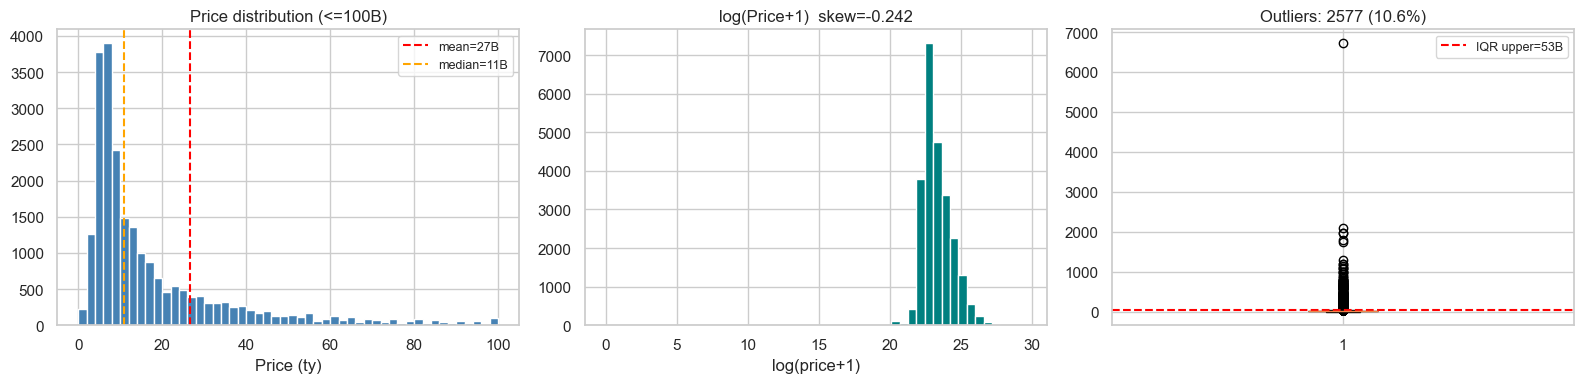

In [4]:
price = df_raw["Price(VND)"]
price_ty = price / 1e9
log_price_raw = np.log1p(price)

Q1, Q3 = price.quantile([0.25, 0.75])
IQR = Q3 - Q1
low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df_raw[(price < low) | (price > high)]

print(f"raw skew: {price.skew():.2f}  |  log1p skew: {log_price_raw.skew():.3f}")
print(f"IQR outliers: {len(outliers):,} ({len(outliers)/len(df_raw)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(price_ty[price_ty <= 100], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(price_ty.mean(), color="red", ls="--", label=f"mean={price_ty.mean():.0f}B")
axes[0].axvline(price_ty.median(), color="orange", ls="--", label=f"median={price_ty.median():.0f}B")
axes[0].set(title="Price distribution (<=100B)", xlabel="Price (ty)")
axes[0].legend(fontsize=9)

axes[1].hist(log_price_raw, bins=50, color="teal", edgecolor="white")
axes[1].set(title=f"log(Price+1)  skew={log_price_raw.skew():.3f}", xlabel="log(price+1)")

axes[2].boxplot(price_ty, patch_artist=True, boxprops=dict(facecolor="lightcoral"))
axes[2].axhline(high / 1e9, color="red", ls="--", label=f"IQR upper={high/1e9:.0f}B")
axes[2].set(title=f"Outliers: {len(outliers)} ({len(outliers)/len(df_raw)*100:.1f}%)")
axes[2].legend(fontsize=9)
plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig("figures/price_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


**Note:** the skew value quoted here (computed on the raw, uncleaned data)
is -0.242. After the full cleaning pipeline below (percentile clipping,
dropping unparsable rows, etc.), the skew of `log_price` on the *final*
21,595-row dataset is different (~0.73) — these describe different stages
of the pipeline, not a contradiction, but worth keeping straight when
writing up results (the original paper's abstract could be read as implying
the final training skew was -0.242, which it is not).

## 4. Preprocessing pipeline

In [5]:
df = clean(df_raw)
print(f"{len(df_raw):,} -> {len(df):,} rows after cleaning")
print(f"final log_price skew: {df['log_price'].skew():.4f}")
Path("data/processed").mkdir(parents=True, exist_ok=True)
df.to_csv("data/processed/houses_hcm_clean.csv", index=False, encoding="utf-8-sig")
df.head()


24,323 -> 21,595 rows after cleaning
final log_price skew: 0.7307


,Price(VND),Acreage,Area,Bedrooms,Floors,Parking,Address,District,width,length,frontage_ratio,Ward,log_price,price_per_m2
0,6.700000e+09,82,6x14m,4,3.0,1,"Đường Thái Thị Giữ, Xã Bà Điểm, Hồ Chí Minh",Xã Bà Điểm,6.0,14.0,0.428571,Xã Bà Điểm,22.625373,8.170732e+07
1,1.900000e+10,51,"4,6x11m",5,5.0,1,"Đường Nguyễn Thiện Thuật, Phường Bàn Cờ, Hồ Ch...",Phường Bàn Cờ,6.0,11.0,0.545455,Phường Bàn Cờ,23.667705,3.725490e+08
2,2.900000e+10,178,"9,2x18m",4,2.0,0,"Đường Số 2, Phường Thủ Đức, Hồ Chí Minh",Phường Thủ Đức,2.0,18.0,0.111111,Phường Thủ Đức,24.090562,1.629213e+08
3,4.900000e+10,103,"6,2x17m",6,2.0,0,"Đường Trần Quốc Toản, Phường Xuân Hòa, Hồ Chí ...",Phường Xuân Hòa,2.0,17.0,0.117647,Phường Xuân Hòa,24.615086,4.757282e+08
4,6.500000e+10,81,"5,6x16m",9,6.0,0,"Đường Nguyễn Tri Phương, Phường Vườn Lài, Hồ C...",Phường Vườn Lài,6.0,16.0,0.375000,Phường Vườn Lài,24.897653,8.024691e+08


## 5. Geographic EDA

Median price per m² varies by more than 10x across wards, motivating the
`communityAverage` feature introduced later.

Top 5 wards by median price/m2:
Ward
Phường Sài Gòn         648.5M/m2
Phường Bến Thành       531.8M/m2
Phường Cầu Ông Lãnh    371.4M/m2
Phường Tân Định        351.4M/m2
Phường Xuân Hòa        350.0M/m2
Name: price_per_m2, dtype: str


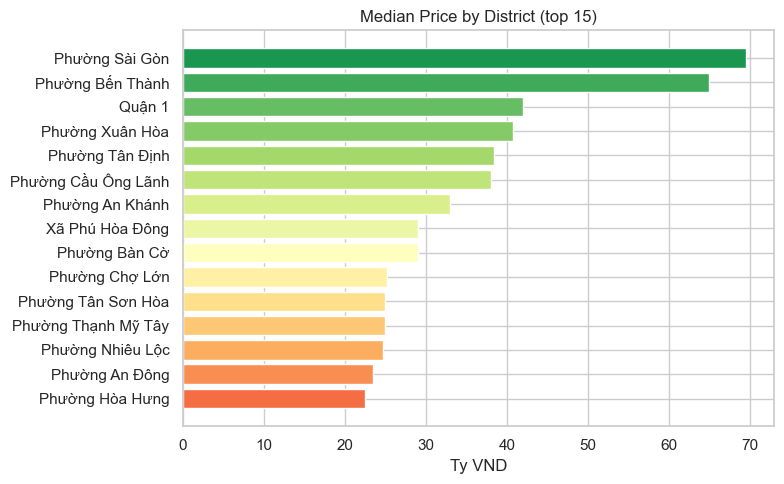

In [6]:
top_wards = (
    df.groupby("Ward")["price_per_m2"]
    .median()
    .sort_values(ascending=False)
    .head(5)
)
print("Top 5 wards by median price/m2:")
print(top_wards.apply(lambda x: f"{x/1e6:.1f}M/m2"))

fig, ax = plt.subplots(figsize=(8, 5))
dist_med = df.groupby("District")["Price(VND)"].median().sort_values().tail(15) / 1e9
ax.barh(dist_med.index, dist_med.values, color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(dist_med))))
ax.set(title="Median Price by District (top 15)", xlabel="Ty VND")
plt.tight_layout()
plt.savefig("figures/eda_district.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Train/test split & feature encoding (9 baseline features)

`District` and `Ward` are target-encoded (median log-price per category),
**fit only on the training fold** and then applied to the test fold, to
avoid leakage.

In [7]:
from sklearn.model_selection import train_test_split

X = df[BASE_FEATURES].copy()
y = df["log_price"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_enc, X_test_enc, base_maps = build_encoded_features(X_train, X_test, y_train)

print(f"train: {X_train_enc.shape}  test: {X_test_enc.shape}")
X_train_enc.head()


train: (17276, 9)  test: (4319, 9)


,Acreage,Bedrooms,Floors,Parking,width,length,frontage_ratio,District_enc,Ward_enc
19754,72,4,4.0,0,5.0,17.0,0.294118,23.814308,23.814308
6243,70,6,4.0,1,4.0,17.0,0.235294,23.880040,23.880040
8986,68,4,3.0,0,4.0,17.0,0.235294,22.617628,22.617628
9419,40,3,4.0,0,4.0,10.0,0.400000,24.073170,24.073170
10154,26,3,3.0,0,3.0,8.0,0.375000,23.362323,23.362323


## 7. Model benchmark — 9 baseline features

Five models: Random Forest, XGBoost, LightGBM, Hybrid Regression
(equal-weight average of the three), and Stacked Generalization
(RF + LightGBM base learners, XGBoost meta-learner, 5-fold CV).

In [8]:
results_df, fitted_base = run_full_benchmark(X_train_enc, y_train, X_test_enc, y_test)
results_df


,name,train_rmsle,test_rmsle,time
0,Hybrid Regression,0.271811,0.345841,0.0
1,Stacked Generalization,0.337578,0.348727,22.4
2,XGBoost,0.308479,0.349195,0.5
3,LightGBM,0.307177,0.350331,0.2
4,Random Forest,0.213571,0.353462,4.8


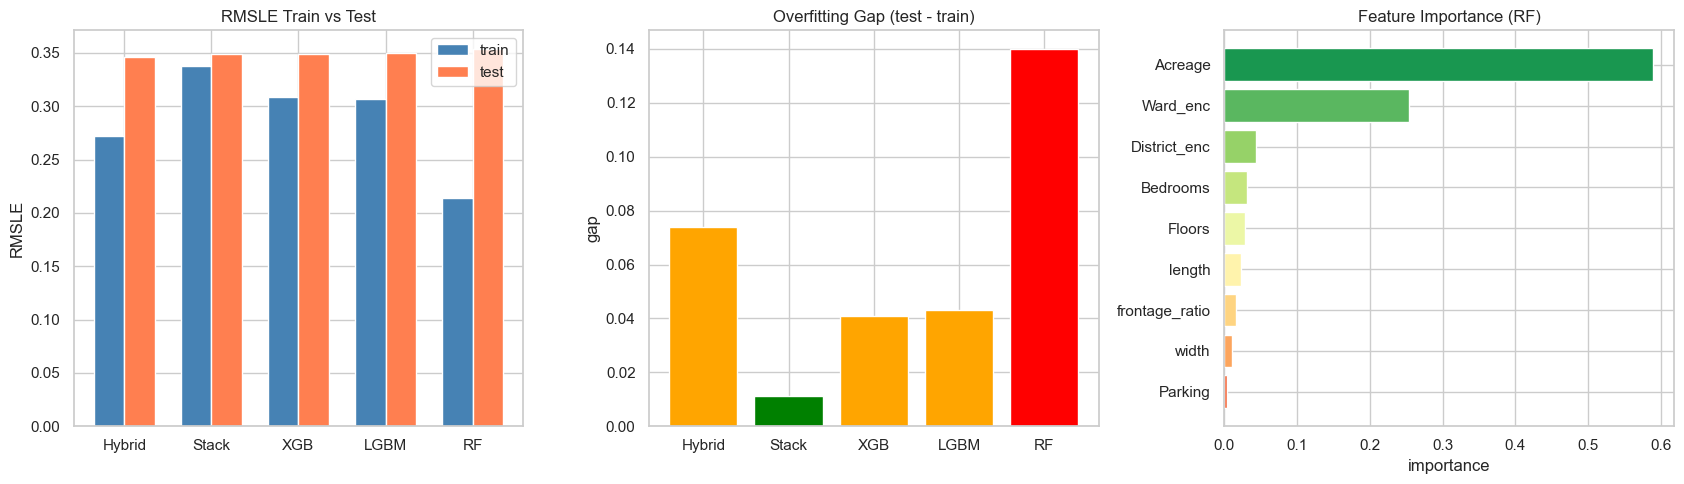

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))
short = {"Random Forest": "RF", "XGBoost": "XGB", "LightGBM": "LGBM",
         "Hybrid Regression": "Hybrid", "Stacked Generalization": "Stack"}
names = [short[n] for n in results_df["name"]]
x, w = np.arange(len(names)), 0.35

ax1.bar(x - w/2, results_df["train_rmsle"], w, label="train", color="steelblue")
ax1.bar(x + w/2, results_df["test_rmsle"], w, label="test", color="coral")
ax1.set_xticks(x); ax1.set_xticklabels(names)
ax1.set(title="RMSLE Train vs Test", ylabel="RMSLE")
ax1.legend()

gap = (results_df["test_rmsle"] - results_df["train_rmsle"]).values
colors = ["red" if g > 0.08 else "orange" if g > 0.04 else "green" for g in gap]
ax2.bar(x, gap, color=colors)
ax2.set_xticks(x); ax2.set_xticklabels(names)
ax2.set(title="Overfitting Gap (test - train)", ylabel="gap")

rf_model = fitted_base["Random Forest"]
fi = pd.Series(rf_model.feature_importances_, index=X_train_enc.columns).sort_values()
ax3.barh(fi.index, fi.values, color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi))))
ax3.set(title="Feature Importance (RF)", xlabel="importance")

plt.tight_layout()
plt.savefig("figures/model_results.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. XGBoost hyperparameter tuning (GridSearchCV)

The winning configuration found here (`learning_rate=0.1, max_depth=6,
n_estimators=400`) is hardcoded as `XGB_TUNED_PARAMS` in `src/models.py`
and reused everywhere downstream, so there is a single source of truth for
"the tuned XGBoost" instead of retyping the parameters by hand in multiple
places (which previously caused a mismatch between two parts of the
original notebook).

In [10]:
from src.models import tune_xgboost

grid = tune_xgboost(X_train_enc, y_train)
print("best params found by this search:", grid.best_params_)
print("hardcoded XGB_TUNED_PARAMS:      ", {k: XGB_TUNED_PARAMS[k] for k in grid.best_params_})


Fitting 5 folds for each of 8 candidates, totalling 40 fits
best params found by this search: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400}
hardcoded XGB_TUNED_PARAMS:       {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400}


## 9. XGBoost learning-rate sweep (extra metrics: R2, MAE, MSE, RMSLE)

In [11]:
lr_df = learning_rate_sweep(X_train_enc, y_train, X_test_enc, y_test)
lr_df.round(5)


,learning_rate,r2_train,r2_test,mae_train,mae_test,mse_train,mse_test,rmsle_train,rmsle_test
0,0.01,0.83207,0.80919,0.28158,0.29407,0.13667,0.15627,0.36969,0.39530
1,0.05,0.87600,0.84580,0.23684,0.25800,0.10092,0.12628,0.31767,0.35536
2,0.10,0.87745,0.84582,0.23531,0.25816,0.09974,0.12627,0.31581,0.35534
3,0.20,0.87393,0.84264,0.23885,0.26046,0.10260,0.12887,0.32031,0.35898
4,0.30,0.87267,0.84020,0.23964,0.26226,0.10363,0.13087,0.32191,0.36176


## 10. Adding the `communityAverage` feature (leak-free)

`communityAverage` = median price/m² per Ward. **Fixed vs. the original
notebook:** this is now computed from the training fold's `price_per_m2`
only, then mapped onto both train and test — the same leak-free pattern
used for `District_enc`/`Ward_enc`.

In [12]:
X2 = df[BASE_FEATURES].copy()
X2["communityAverage"] = 0.0  # placeholder; recomputed leak-free below
y2 = df["log_price"].copy()
price_per_m2 = df["price_per_m2"].copy()

X2_train, X2_test, y2_train, y2_test, ppm2_train, ppm2_test = train_test_split(
    X2, y2, price_per_m2, test_size=0.2, random_state=42
)
X2_train_enc, X2_test_enc, comm_maps = build_encoded_features(
    X2_train, X2_test, y2_train, price_per_m2_train=ppm2_train
)

print("top 5 wards by (train-only) median price/m2:")
print(comm_maps["community_avg"].sort_values(ascending=False).head()
      .apply(lambda v: f"{v/1e6:.1f}M/m2"))
X2_train_enc.head()


top 5 wards by (train-only) median price/m2:
Ward
Phường Sài Gòn         665.8M/m2
Phường Bến Thành       539.8M/m2
Phường Cầu Ông Lãnh    380.0M/m2
Phường Xuân Hòa        354.5M/m2
Phường Tân Định        351.5M/m2
Name: price_per_m2, dtype: str


,Acreage,Bedrooms,Floors,Parking,width,length,frontage_ratio,communityAverage,District_enc,Ward_enc
19754,72,4,4.0,0,5.0,17.0,0.294118,2.450000e+08,23.814308,23.814308
6243,70,6,4.0,1,4.0,17.0,0.235294,2.954545e+08,23.880040,23.880040
8986,68,4,3.0,0,4.0,17.0,0.235294,1.286274e+08,22.617628,22.617628
9419,40,3,4.0,0,4.0,10.0,0.400000,3.333333e+08,24.073170,24.073170
10154,26,3,3.0,0,3.0,8.0,0.375000,2.403846e+08,23.362323,23.362323


In [13]:
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

rf2, xgb2, lgbm2 = (
    RandomForestRegressor(**RF_PARAMS),
    XGBRegressor(**XGB_TUNED_PARAMS),
    LGBMRegressor(**LGBM_PARAMS),
)
for name, m in [("Random Forest", rf2), ("XGBoost", xgb2), ("LightGBM", lgbm2)]:
    m.fit(X2_train_enc, y2_train)

comm_scores = {
    "XGBoost": rmsle(y2_test, xgb2.predict(X2_test_enc)),
    "LightGBM": rmsle(y2_test, lgbm2.predict(X2_test_enc)),
    "Hybrid Regression": rmsle(y2_test, blend([rf2, xgb2, lgbm2], X2_test_enc)),
}
baseline_scores = results_df.set_index("name")["test_rmsle"]
cmp_df = pd.DataFrame({
    "before (9 feat.)": {k: baseline_scores[k] for k in comm_scores},
    "after (10 feat.)": comm_scores,
})
cmp_df["delta"] = cmp_df["after (10 feat.)"] - cmp_df["before (9 feat.)"]
cmp_df["% improvement"] = (-cmp_df["delta"] / cmp_df["before (9 feat.)"] * 100).round(1)
cmp_df.round(5)


,before (9 feat.),after (10 feat.),delta,% improvement
XGBoost,0.34920,0.33865,-0.01054,3.0
LightGBM,0.35033,0.33929,-0.01104,3.2
Hybrid Regression,0.34584,0.33324,-0.01260,3.6


## 11. Persist models for inference

Saved with `joblib` so `predict.py` (or any other script) can load them
without retraining. Run `python train.py` from the project root to
(re)generate everything in `models/` from scratch.

In [16]:
import joblib

models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)
joblib.dump(rf2, models_dir / "rf_community.pkl")
joblib.dump(xgb2, models_dir / "xgb_community.pkl")
joblib.dump(lgbm2, models_dir / "lgbm_community.pkl")
joblib.dump(comm_maps, models_dir / "encoding_maps.pkl")
joblib.dump(
    {"global_log_price_median": float(y2_train.median()),
     "global_price_per_m2_median": float(ppm2_train.median())},
    models_dir / "global_medians.pkl",
)
print("saved to", models_dir)

saved to d:\AIL_301m\hcm-house-price-prediction\hcm-house-price-prediction\models


## 12. Prediction demo

In [36]:
import sys
sys.path.insert(0, ".")
from predict import predict_price

test_cases = [
    # acreage, bed, floor, park, width, length, district, ward, actual_ty
    (50, 4,   6,     1,    5,  10, 'Phú Thọ Hòa', 'Tân Phú', 8.5),
    (27.5,       4,   3,     1,    5,  5.5,  'Bình Thạnh',     'Bình Thạnh', 5.68)
]

for acreage, bed, floor, park, w, l, district, ward, actual in test_cases:
    pred = predict_price(acreage, bed, floor, park, w, l, district, ward) / 1e9
    err = (pred - actual) / actual * 100
    print(f"{ward:15s} {acreage:5.1f}m2  pred={pred:6.2f} ty  actual={actual:6.2f} ty  error={err:+.1f}%")

print("Dữ liệu thật:\nhttps://batdongsan.com.vn/ban-nha-rieng-duong-thoai-ngoc-hau-phuong-phu-tho-hoa-70/ban-6-tang-ngan5m-mat-tien-uong-va-luy-ban-bich-chu-gap-ban-ve-ha-noi-8-5-ty-pr45272167")
print("\nhttps://batdongsan.com.vn/ban-nha-rieng-duong-xo-viet-nghe-tinh-phuong-25-66/chinh-chu-ban-378-18-xvnt-5-68-ty-moi-full-noi-that-pr44993538")

Tân Phú          50.0m2  pred=  8.93 ty  actual=  8.50 ty  error=+5.0%
Bình Thạnh       27.5m2  pred=  4.72 ty  actual=  5.68 ty  error=-16.8%
Dữ liệu thật:
https://batdongsan.com.vn/ban-nha-rieng-duong-thoai-ngoc-hau-phuong-phu-tho-hoa-70/ban-6-tang-ngan5m-mat-tien-uong-va-luy-ban-bich-chu-gap-ban-ve-ha-noi-8-5-ty-pr45272167

https://batdongsan.com.vn/ban-nha-rieng-duong-xo-viet-nghe-tinh-phuong-25-66/chinh-chu-ban-378-18-xvnt-5-68-ty-moi-full-noi-that-pr44993538


## 13. Conclusion

- Ensemble methods (Hybrid Regression, Stacked Generalization) outperform
  individual models; Stacked Generalization has the smallest overfitting
  gap thanks to 5-fold CV, while Hybrid Regression gets the lowest
  absolute test RMSLE.
- Adding a leak-free `communityAverage` feature improves all three
  top models' test RMSLE, confirming neighbourhood-level price context
  matters even in this smaller, HCMC-specific dataset.
- Absolute RMSLE here is higher than Truong et al. (2020)'s Beijing
  result, mainly because this dataset is ~11x smaller and has fewer
  engineered features (no age, no distance-to-CBD, no market-wide
  community pricing index).

See `README.md` for the full write-up and `docs/paper.pdf` for the
original course paper.